# 03 — Transfer Learning & Training MobileNetV2

| Fase | Base Model | Epochs | LR |
|------|-----------|--------|----|
| 1. Feature Extraction | **Frozen** | 10 | 1e-3 |
| 2. Fine-Tuning | **Partial Unfreeze** (layer ≥100) | 10 | 1e-4 |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

from src.config import *
from src.train import (
    remove_broken_images, get_callbacks, get_generators,
    build_model, enable_fine_tuning, save_pickle
)

TensorFlow: 2.18.0
GPU: []
✅ Config loaded successfully!
📁 RAW_DIR: C:\Users\ACER\Documents\ANALIS CITRA.py\dataset\raw\Comprehensive Disaster Dataset(CDD)
📁 TRAIN_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\train
📁 VAL_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\val
📁 TEST_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\test
📊 Classes: ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Land_Disaster', 'Non_Damage', 'Water_Disaster']
📐 Input Shape: (224, 224, 3)
🔄 FREEZE_EPOCHS: 10
🔄 FINETUNE_EPOCHS: 10


## 1. Validasi & Bersihkan Gambar Rusak

In [2]:
print('Validasi gambar di semua split...')
for d, name in [(TRAIN_DIR,'Train'), (VAL_DIR,'Val'), (TEST_DIR,'Test')]:
    n = remove_broken_images(d)
    print(f'  {name}: {n} file rusak dihapus')
print('\n✅ Dataset bersih!')

Validasi gambar di semua split...
  ✓ Semua valid di train
  Train: 0 file rusak dihapus
  ✓ Semua valid di val
  Val: 0 file rusak dihapus
  ✓ Semua valid di test
  Test: 0 file rusak dihapus

✅ Dataset bersih!


## 2. Load Data Generator

In [3]:
train_gen, val_gen, test_gen = get_generators()

print(f'Train  : {train_gen.samples} gambar, {len(train_gen)} steps/epoch')
print(f'Val    : {val_gen.samples} gambar, {len(val_gen)} steps/epoch')
print(f'Test   : {test_gen.samples} gambar')
print(f'Kelas  : {train_gen.class_indices}')

save_pickle(train_gen.class_indices, '../models/class_indices.pkl')

Found 9485 images belonging to 6 classes.
Found 2030 images belonging to 6 classes.
Found 2040 images belonging to 6 classes.
Train  : 9485 gambar, 297 steps/epoch
Val    : 2030 gambar, 64 steps/epoch
Test   : 2040 gambar
Kelas  : {'Damaged_Infrastructure': 0, 'Fire_Disaster': 1, 'Human_Damage': 2, 'Land_Disaster': 3, 'Non_Damage': 4, 'Water_Disaster': 5}
[saved] ../models/class_indices.pkl


## 3. Contoh Augmentasi

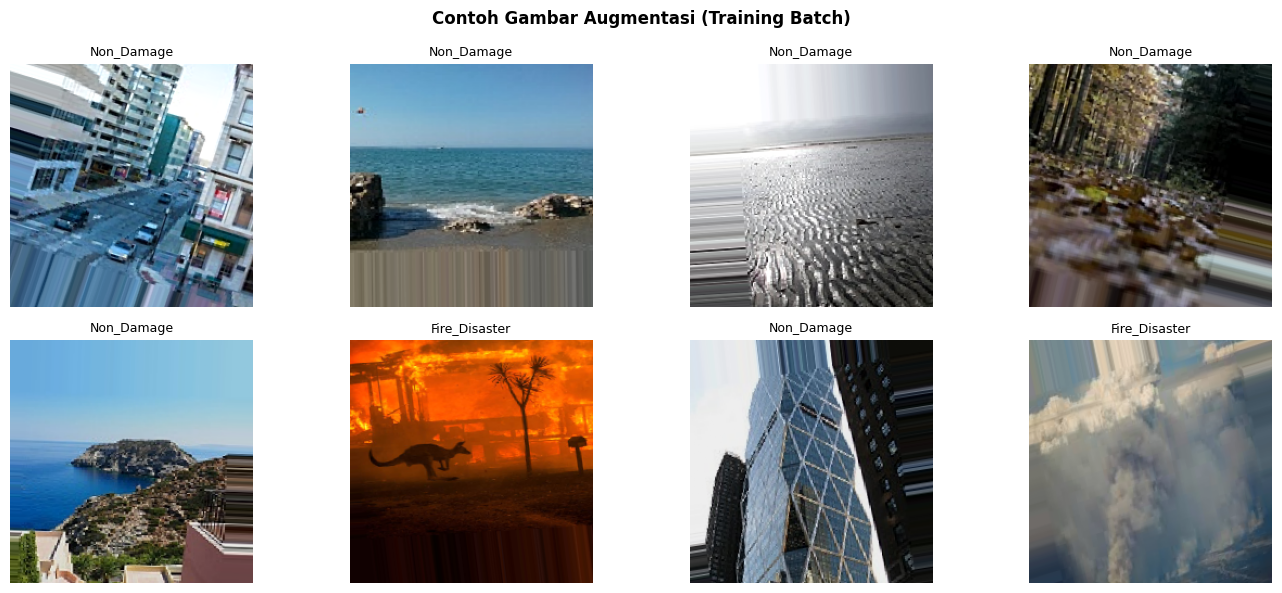

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Ambil 1 batch dan tampilkan 8 gambar
imgs, labels = next(train_gen)
class_names = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    # Denormalize dari preprocess_input [-1,1] ke [0,1] untuk tampil
    img = (imgs[i] + 1.0) / 2.0
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[np.argmax(labels[i])], fontsize=9)
    ax.axis('off')
plt.suptitle('Contoh Gambar Augmentasi (Training Batch)', fontweight='bold')
plt.tight_layout()
os.makedirs('../results/eda', exist_ok=True)
plt.savefig('../results/eda/augmentation_examples.png', dpi=120)
plt.show()

## 4. Build Model MobileNetV2

In [5]:
model, base_model = build_model()
model.summary(line_length=80)

total_p     = model.count_params()
trainable_p = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen_p    = total_p - trainable_p
print(f'\nTotal params    : {total_p:,}')
print(f'Trainable params: {trainable_p:,}  ← hanya head')
print(f'Frozen params   : {frozen_p:,}  ← base MobileNetV2')

Model: "DisasterMobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1 (Conv2D)        │ (None, 112, 112,  │         864 │ input_layer[0][0]  │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn_Conv1              │ (None, 112, 112,  │         128 │ Conv1[0][0]        │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1_relu (ReLU)     │ (None, 112, 112,  │           0 │ bn_Conv1[0][0]     │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 112, 112,  │         288 │ Conv1_relu[0][0]   │
│ (DepthwiseConv2D)     │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 112, 112,  │         128 │ expanded_conv_dep… │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 112, 112,  │           0 │ expanded_conv_dep… │
│ (ReLU)                │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_project │ (None, 112, 112,  │         512 │ expanded_conv_dep… │
│ (Conv2D)              │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_projec… │ (None, 112, 112,  │          64 │ expanded_conv_pro… │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand        │ (None, 112, 112,  │       1,536 │ expanded_conv_pro… │
│ (Conv2D)              │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_BN     │ (None, 112, 112,  │         384 │ block_1_expand[0]… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_relu   │ (None, 112, 112,  │           0 │ block_1_expand_BN… │
│ (ReLU)                │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_pad           │ (None, 113, 113,  │           0 │ block_1_expand_re… │
│ (ZeroPadding2D)       │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise     │ (None, 56, 56,    │         864 │ block_1_pad[0][0]  │
│ (DepthwiseConv2D)     │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_BN  │ (None, 56, 56,    │         384 │ block_1_depthwise… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_re… │ (None, 56, 56,    │           0 │ block_1_depthwise… │
│ (ReLU)                │ 96)  

 Total params: 2,624,710 (10.01 MB)

 Trainable params: 364,166 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Total params    : 2,624,710
Trainable params: 364,166  ← hanya head
Frozen params   : 2,260,544  ← base MobileNetV2


## 5. Phase 1 — Feature Extraction
Base model **frozen** — hanya head (Dense layers) yang dilatih.

In [6]:
print(f'Training Phase 1: {FREEZE_EPOCHS} epochs, LR={LEARNING_RATE}')

hist1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = FREEZE_EPOCHS,
    callbacks       = get_callbacks('freeze'),
    verbose         = 1,
)
save_pickle(hist1.history, '../models/history_freeze.pkl')
print(f'\nBest val_accuracy Phase 1: {max(hist1.history["val_accuracy"]):.4f}')

Training Phase 1: 10 epochs, LR=0.001
Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.7819 - loss: 0.6871
Epoch 1: val_accuracy improved from None to 0.88916, saving model to c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\checkpoints\best_freeze.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 140s 458ms/step - accuracy: 0.8460 - loss: 0.4867 - val_accuracy: 0.8892 - val_loss: 0.3192 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8972 - loss: 0.3264
Epoch 2: val_accuracy improved from 0.88916 to 0.90837, saving model to c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\checkpoints\best_freeze.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 144s 485ms/step - accuracy: 0.8959 - loss: 0.3296 - val_accuracy: 0.9084 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9057 - loss: 0.2758
Epoch 3: val_accuracy did not improve from 0.90837
297/297 ━━━━━━━━━━━━━━━━━━━━ 146s 

## 6. Phase 2 — Fine-Tuning
Unfreeze layer atas MobileNetV2 (dari layer ke-100), LR sangat kecil.

In [7]:
model = enable_fine_tuning(model, base_model)
print(f'Training Phase 2: {FINETUNE_EPOCHS} epochs, LR={FINETUNE_LR}')

hist2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = FINETUNE_EPOCHS,
    callbacks       = get_callbacks('finetune'),
    verbose         = 1,
)
save_pickle(hist2.history, '../models/history_finetune.pkl')
print(f'\nBest val_accuracy Phase 2: {max(hist2.history["val_accuracy"]):.4f}')

[Fine-Tune] Trainable layers di base: 54 (dari layer ke-100)
Training Phase 2: 10 epochs, LR=0.0001
Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.8734 - loss: 0.3616
Epoch 1: val_accuracy improved from None to 0.89310, saving model to c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\checkpoints\best_finetune.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 182s 587ms/step - accuracy: 0.8928 - loss: 0.3195 - val_accuracy: 0.8931 - val_loss: 0.4524 - learning_rate: 1.0000e-04
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.9210 - loss: 0.2306
Epoch 2: val_accuracy improved from 0.89310 to 0.91823, saving model to c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\checkpoints\best_finetune.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 178s 599ms/step - accuracy: 0.9239 - loss: 0.2288 - val_accuracy: 0.9182 - val_loss: 0.3142 - learning_rate: 1.0000e-04
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9365 - loss: 0.1970
Epoch 3: va

## 7. Simpan Model & History

In [8]:
# Gabung history kedua fase
combined = {}
for key in hist1.history:
    combined[key] = hist1.history[key] + hist2.history.get(key, [])
save_pickle(combined, '../models/history.pkl')

os.makedirs('../models', exist_ok=True)
model.save('../models/final_model.keras')
print('✅ Model tersimpan: ../models/final_model.keras')

[saved] ../models/history.pkl
✅ Model tersimpan: ../models/final_model.keras


## 8. Kurva Training

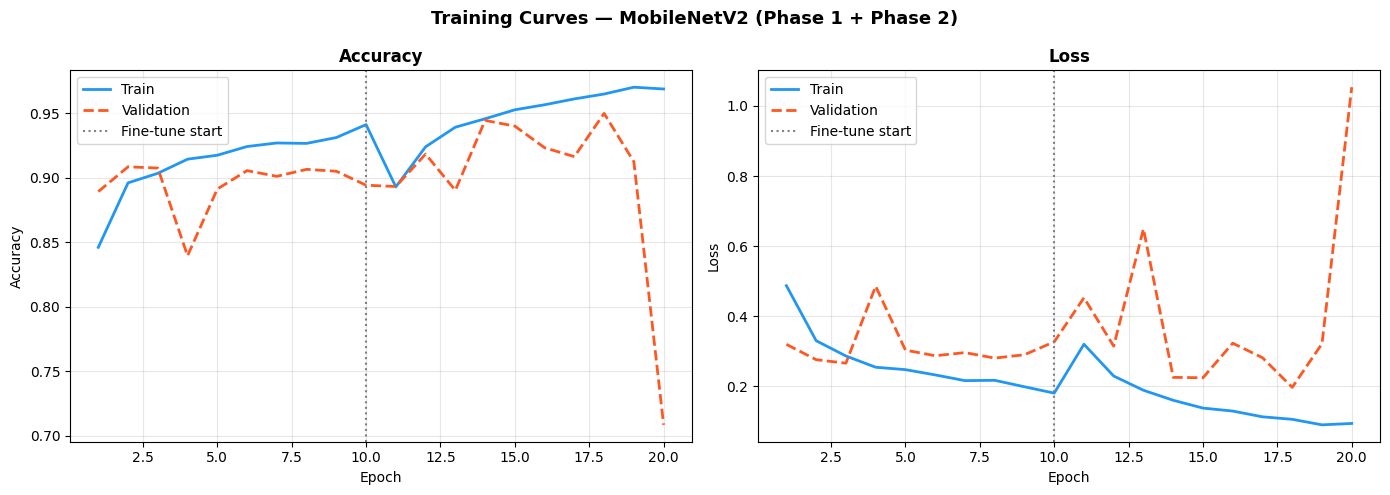

[saved] results/training/training_curves.png


In [9]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(combined['accuracy']) + 1)
freeze_end   = FREEZE_EPOCHS  # garis pemisah antara fase 1 & 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs_range, combined['accuracy'],     label='Train', color='#2196F3', lw=2)
ax1.plot(epochs_range, combined['val_accuracy'], label='Validation', color='#FF5722', lw=2, ls='--')
ax1.axvline(freeze_end, color='gray', ls=':', lw=1.5, label='Fine-tune start')
ax1.set_title('Accuracy', fontweight='bold', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(epochs_range, combined['loss'],     label='Train', color='#2196F3', lw=2)
ax2.plot(epochs_range, combined['val_loss'], label='Validation', color='#FF5722', lw=2, ls='--')
ax2.axvline(freeze_end, color='gray', ls=':', lw=1.5, label='Fine-tune start')
ax2.set_title('Loss', fontweight='bold', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training Curves — MobileNetV2 (Phase 1 + Phase 2)', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../results/training', exist_ok=True)
plt.savefig('../results/training/training_curves.png', dpi=150)
plt.show()
print('[saved] results/training/training_curves.png')

---
### ✅ Training selesai!
Lanjut ke `04_Model_Evaluation.ipynb`